# Dimensionality reduction - t-SNE Analysis and visualisation

*Leonardo Portes, Jeremie Giraud <br>
Adapted by Michel M. Nzikou and Jeremie Giraud*

#### Publication for the Haralick feature extraction and tSNE analysis:
Feature fusion-enhanced t-SNE image atlas for geophysical features discovery
*Leonardo Portes*<sup>1,2,3,*</sup>, Guillaume Pirot<sup>3</sup>, Michel M. Nzikou<sup>3</sup>, Jeremie Giraud<sup>3,4</sup>, Mark Lindsay<sup>2,3,5</sup>, Mark Jessell<sup>2,3</sup>, Edward Cripps<sup>1,2</sup>

<sup>1</sup> Department of Mathematics and Statistics, The University of Western Australia, 35 Stirling Highway, Crawley 6009, Australia  
<sup>2</sup> ARC Centre for Data Analytics for Resources and Environments (DARE), Perth and Sydney, Australia  
<sup>3</sup> Centre for Exploration Targeting, School of Earth and Oceans, The University of Western Australia, 35 Stirling Highway, Crawley 6009, Australia  
<sup>4</sup> RING Team, GeoRessources, Université de Lorraine, CNRS, Vandoeuvre-les-Nancy, F-54000, France  
<sup>5</sup> Commonwealth Scientific and Industrial Research Organization, Mineral Resources, 26 Dick Perry Ave, Kensington, WA 6151, Australia  

*Corresponding author:* *ll.portes@gmail.com*


## Summary of t-SNE

t-SNE (van der Maaten and Hinton, 2008) defines pairwise similarities as probabilities. In the high-dimensional space, the probability of $x_j$ being a neighbour of $x_i$ is given by:

$$
p_{j|i} = \frac{\exp\left(-\|x_i - x_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\left(-\|x_i - x_k\|^2 / 2\sigma_i^2\right)}
$$

where $\sigma_i$ relates to the perplexity $\tau$. The joint probability $p_{ij}$ is the average of $p_{j|i}$ and $p_{i|j}$:

$$
p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}
$$

In the lower-dimensional embedding, similarities between $y_i$ and $y_j$ are modeled using a Student t-distribution with one degree of freedom:

$$
q_{ij} = \frac{\left(1 + \|y_i - y_j\|^2\right)^{-1}}{\sum_{k \neq l} \left(1 + \|y_k - y_l\|^2\right)^{-1}}
$$

The t-SNE algorithm minimizes the Kullback-Leibler divergence between $P$ and $Q$ using gradient descent, optimizing the low-dimensional representation to best reflect the original data relationships.

---

### Perplexity and Neighborhoods

The balance between preserving local and global relationships in t-SNE is influenced by the user-defined hyperparameter perplexity, $\tau$.

Perplexity acts as a smooth measure of the effective number of neighbours considered for each data point, guiding the algorithm in determining the scale at which data relationships should be maintained. Specifically, $\tau$ determines the variance $\sigma_i^2$ of the Gaussian distribution centered on each data point $x_i$, which in turn defines the neighborhood's spread.

The algorithm adjusts $\sigma_i$ such that the perplexity — essentially a normalized measure of neighborhood size — matches the user-specified $\tau$. Therefore:

- Higher $\tau$ values result in larger $\sigma_i$, encompassing more distant neighbours and focusing on global structures.
- Lower $\tau$ values yield smaller $\sigma_i$, emphasizing local data structures.

---

### References
For further details on best practices, pitfalls, and advanced usage of t-SEN, see Kobak and Berens (2019); Luecken and Theis (2019); Wattenberg et al. (2016).


- Kobak, D. and Berens, P. (2019). *The art of using t-SNE for single-cell transcriptomics*. Nat Commun, 10, 5416. https://doi.org/10.1038/s41467-019-13056-x  
- van der Maaten, L. and Hinton, G. *Visualizing Data using t-SNE*, Journal of Machine Learning Research, 9, 2579–2605, (2008).
- Luecken, M. D. and Theis, F. J. (2019). *Current best practices in single‐cell RNA‐seq analysis: a tutorial*. Mol Syst Biol, 15. https://doi.org/10.15252/msb.20188746  
- Wattenberg, M., Viégas, F., and Johnson, I. (2016). *How to Use t-SNE Effectively*. Distill, 1. https://doi.org/10.23915/distill.00002


## Licence

This work is licensed under a  
[Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License](https://creativecommons.org/licenses/by-nc-nd/4.0/).

![CC BY-NC-ND 4.0](https://licensebuttons.net/l/by-nc-nd/4.0/88x31.png)

<div class="alert alert-block alert-warning">
This work has not yet been released to the public and contains unpublished research material. You cannot use it for commercial purposes or for publication until it has been released under another license.
</div>

In [ ]:
# !pip install alphashape
# !pip install mahotas
# !pip install ipython

In [ ]:
# # TODO: remove this cell???

# import sys,os
# # Get the directory two levels above
# cwd           = os.getcwd()
# two_levels_up = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
# print(f"two_levels_up {two_levels_up}")

two_levels_up c:\Users\00090846\OneDrive - UWA\Documents\GitHub


In [ ]:
# Loading mmodules
%matplotlib inline
# Loading data
import os
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt # for plotting
from time import time
import seaborn as sns
import os
from matplotlib import image as plt_image
from tqdm import tqdm 

# TODO: remove useless imports.

import mahotas # Haralick features
from joblib import Parallel, delayed

from bokeh.plotting import figure, show, output_notebook, output_file, save
from bokeh.transform import factor_cmap, factor_mark
from bokeh.palettes import Spectral5, Colorblind5
from bokeh.layouts import gridplot
from bokeh.models import HoverTool, ColumnDataSource, CategoricalColorMapper, CDSView, GroupFilter, Legend
output_notebook()

Loading BokehJS ...

### Define functions calculating Haralick features and t-SNE

In [ ]:
# Import necessary modules.
import mahotas 
from openTSNE import TSNE

def get_haralick_features(image, distance=1):
    """
    A function to calculate the Haralick features.
    """

    # image: 
        # A grayscale image (2D NumPy array) from which texture features will be extracted
    # return_mean: Haralick features are computed for different directions (0°, 45°, 90°, 135°).
        # If True, it returns the mean of the features across all directions, simplifying the result to a single feature vector.
        # If False, it returns individual feature vectors for each direction.
    # Distance: 
        # Specifies the pixel distance for computing the GLCM.
        # A higher value considers texture over a larger neighborhood.

    haralick_features = mahotas.features.haralick(image, return_mean=True, distance=distance)

    return haralick_features

def return_tsne(X, perplexity=30, metric="euclidean"):
    """ 
    A function to calculate the t-SNE.
    """
    tsne = TSNE(
        perplexity=perplexity,
        metric=metric,
        n_jobs=24, # more jobs will crash the the kernel!
        random_state=42,
        verbose=False)
    
    return tsne.fit(X)

### Parameters for t-SNE function `TSNE`: <br>
`perplexity`
Controls the balance between local and global structure in the t-SNE embedding.
Higher values make t-SNE consider more global relationships; lower values focus more on local structure.
Typically ranges from 5 to 50.
Here: recommended -> 30.
 <br> <br>
`metric`
Defines the distance function used to measure similarity between points in the high-dimensional space.
Common choices: "euclidean", "cosine", "manhattan", or even custom distance functions.
 <br> <br>
`n_jobs`
Sets the number of parallel jobs for computation.
More jobs can speed up processing, but too many can overload system memory and crash the kernel.
Here: recommended max -> 24.
 <br> <br>
`random_state`
Ensures reproducibility by setting a fixed seed for random number generation.
 <br> <br>
`verbose`
Controls whether to print progress messages.

More on t-SNE: <br>
https://distill.pub/2016/misread-tsne/

### Functions for preprocessing and plotting.
- Rescaling model values as images 
- Calculating the Haralick features

In [12]:
from sklearn.preprocessing import StandardScaler

# Useful to define filename when saving results. 
from pathlib import Path
file_prefix = Path(save_dir).stem # without extension

# Pre-processing
def rescale_0_255_uint8(data, data_min, data_max, use_provided_extrema=False):
    """ Pre-processing for Haralick feature calculataion. """

    # Normalise and multiply by 255 for consistency with an image. 
    if use_provided_extrema:
        # Proposed by JG. 
        res = 255 * (data - data_min)/(data_max - data_min)
    else:
        # Original from LP. 
        res = 255 * (data - data.min())/(data.max() - data.min())

    # make it an array of int8 and return. 
    res = np.array(res, dtype=np.uint8)
    return res

# Haralick titles
def haralick_df(tiles_list): 
    """
    Get the Haralick features for each image (tile) in the list provided.
    """
    res = Parallel(n_jobs=-2)(delayed(get_haralick_features)(tile) for tile in tiles_list)
    res = np.array(res)
    
    # rescaling the feature vectors
    scaler = StandardScaler() 
    scaler.fit(res) 
    X = scaler.transform(res)
    res = np.empty(1) # freeing memory
    
    # Pandas dataframe
    feat_lbls = [r"$f_{%i}$"%(i+1) for i in range(13)]
    return pd.DataFrame(X, columns=feat_lbls)

#### Checks

## 3. Data loading and pre-processing

Let's load the models produce by a pseudo trans-dimensional MCMC chain, consisting of the sampling of 500,000 models.   
Here, it is decimated for speed of analysis, and easier handing and visualisation. 

We will consider two chains, simulating different levels of difficulty to recover the same model, in order to assess the limits of the algorithm. 

- **first chain**: chain_ID_7136 - 2 missing units from the prior model; data witn noise. 
<img src="figures/fig_chain_ID_7136_.png" alt="Description" width="700"/>
<br>

- **second chain**: chain_ID_9895 - 2 missing units from the prior model and one 'wrong' unit introducing a bias; data witn noise. 
<img src="figures/fig_chain_ID_9895_.png" alt="Description" width="700"/>



> <br>
>> We want to visualise the different models produced by each chain, and whether the chain_ID_9895 breaks. <br>
>> What are the different families of models that can be identified?
> <br>
> <br>



### Load the models

Loading density models. 

In [29]:
import os

save_dir = "decimated_chain_ID_9895"  # Chain with bad prior model, missing units and noisy data 
# save_dir = "decimated_chain_ID_7136"  # Chain with missing units and noisy data 
n_parts = 20
# Get the split matrices.
loaded_parts = [np.load(os.path.join(save_dir, f"matrix_part_{i}.npy")) for i in range(n_parts)]
# Concatenate along the last dimension
density_models = np.concatenate(loaded_parts, axis=-1)


## 4. Calculation of the Haralick features
Here it is possible to change the parameter `decimate`, which gives the number of models to keep from the original datasets.

In [30]:
data_type = "density_models" 

# Decimate
decimate = 5 # To keep one model every 5 from the loaded dataset.

decimated_density_models = density_models[::-1, :, :, ::decimate]
print("Analysis using " + str(np.shape(decimated_density_models)[-1]) + " models")

#-- Haralick features. Pre-processing. Output is a Python list
t0 = time()

# rescale to [0,1] and convert to int8
data_min = np.min(decimated_density_models.copy())
data_max = np.max(decimated_density_models.copy())
data_models_0_255 = Parallel(n_jobs=-2)(delayed(rescale_0_255_uint8)(decimated_density_models[:,:,:,i], data_min, data_max, use_provided_extrema=False)
                                        for i in range(decimated_density_models.shape[3]))

elapsed = time() - t0
print("Data Rescaling Runtime: ", round(elapsed,3), "sec")

#-- Haralick features (standardized)
t0 = time()
df_h = haralick_df(data_models_0_255) 
elapsed = time() - t0
print("Calculation of Haralick feature runtime:", round(elapsed,3), "sec")


Analysis using 100 models
Data Rescaling Runtime:  4.239 sec
Calculation of Haralick feature runtime: 3.79 sec


## t-SNE calculation and plot. 
Here it is possible to change the parameter `perplexity`

In [32]:
# Define functions for t-SNE calculation and plot.
from sklearn.preprocessing import MinMaxScaler

def plot_tsne(perplexity, file_prefix, df_h):
    """
    Perform t-SNE calculation and plot the results.
    
    Parameters:
    perplexity (int): Perplexity parameter for t-SNE.
    file_prefix (str): Prefix of the file name.
    df_h (pd.DataFrame): Input data for t-SNE.
    
    Returns:
    str: Confirmation message.
    """
    # Perform t-SNE transformation.
    temp = return_tsne(df_h.values, perplexity)
    df_tsne_density = pd.DataFrame(temp, columns=[f"comp_{i+1}" for i in range(temp.shape[1])])
    
    # Compute reduced colors.
    reduced_colors = df_tsne_density.values.copy()
    d_center = np.sqrt(reduced_colors[:, 0]**2 + reduced_colors[:, 1]**2)
    reduced_colors = np.hstack((reduced_colors, d_center[:, None]))
    
    # Normalize colors.
    scaler = MinMaxScaler(feature_range=(0, 1))
    reduced_colors = scaler.fit_transform(reduced_colors)
    reduced_colors /= reduced_colors.max()
    
    # Plot t-SNE results.
    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    scatter = ax.scatter(
        df_tsne_density.iloc[:, 0], df_tsne_density.iloc[:, 1],
        s=5, c=reduced_colors, edgecolors='none', rasterized=True
    )
    
    ax.set_title(f't-SNE Visualization | {file_prefix}', fontsize=14)
    ax.set_xlabel("Component 1", fontsize=12)
    ax.set_ylabel("Component 2", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.suptitle(file_prefix, fontsize=14)
    plt.show()
    print("t-SNE visualization successfully generated.")
    
    return df_tsne_density 


Calculating t-SNE


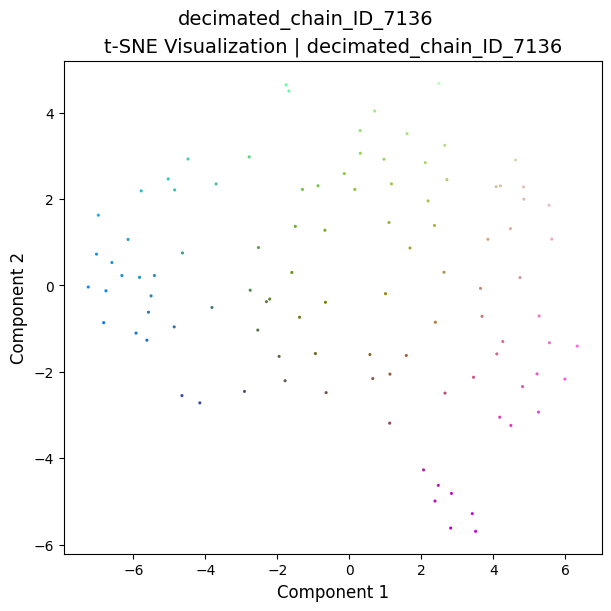

t-SNE visualization successfully generated.
Calculation and plot t-SNE Runtime: 16.285 sec


In [33]:
print('Calculating t-SNE')

t0              = time()
perplexity      = 30  # Parameter that can be tuned. TODO add link to online illustration website?
df_tsne_density = plot_tsne(perplexity, file_prefix, df_h)
elapsed         = time() - t0
print("Calculation and plot t-SNE Runtime:", round(elapsed,3), "sec")

In [34]:
# Embedding images into the data frame
from io import BytesIO
from PIL import Image
import base64
import pandas as pd

def embed_images(slice_iy, data_models_0_255, df_tsne_density):
    """
    Embed images into the data frame as base64 encoded strings.
    
    Parameters:
    slice_iy (int): Index for slicing the image data.
    data_models_0_255 (list): List of image arrays.
    df_tsne_density (pd.DataFrame): Data frame to store encoded images.
    
    Returns:
    pd.DataFrame: Updated data frame with embedded images.
    """
    def embeddable_image(img_data):
        image = Image.fromarray(img_data, mode='L')
        buffer = BytesIO()
        image.save(buffer, format='png')
        for_encoding = buffer.getvalue()
        return 'data:image/png;base64,' + base64.b64encode(for_encoding).decode()
    
    df_tsne_density["image"] = [embeddable_image(tile[:, slice_iy, :]) for tile in data_models_0_255]
    return df_tsne_density


In [35]:
slice_iy = 15  # Set the slice index
df_tsne_density = embed_images(slice_iy, data_models_0_255, df_tsne_density)
# Check the updated DataFrame
print(df_tsne_density.head())

     comp_1    comp_2                                              image
0 -5.780459  2.189324  data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...
1 -0.678103  1.278793  data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...
2  0.152028  2.223588  data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...
3  0.302281  3.060569  data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...
4 -0.645457 -2.481268  data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAA...


In [36]:
# Matplotlib | plotting tsne mosaic
from matplotlib.image import BboxImage
from matplotlib.transforms import Bbox, TransformedBbox
from bokeh.palettes import Spectral5, Colorblind5  # Unused?

def plot_tsne_static(df_tsne, sizex=1., sizey=1., transparency_marker=1., size_marker=5., fig_w=12, fig_h=8, title=None):

    # xmax = 1.1*np.max(df_tsne['comp_1'].values, axis=None)
    # ymax = 1.2*np.max(df_tsne['comp_2'].values, axis=None)

    fig, ax = plt.subplots(1,1,figsize=(fig_w, fig_h))

    # plotting all data points
    sns.scatterplot(x="comp_1", y="comp_2",data=df_tsne,
                    alpha=transparency_marker, s=size_marker, rasterized=True, ax=ax, zorder=0) # zorder to plot bellow the images

    # plotting the selected images.
    for i, row in df_tsne.iterrows():
        img_temp = row["image"].split("data:image/png;base64,")[1]
        bytes_decoded = base64.b64decode(img_temp)
        img_temp = Image.open(BytesIO(bytes_decoded))
        img_temp = np.array(img_temp.convert("L"))[::-1, :] # to mimic "origin=lower"

        bbox0 = Bbox.from_bounds(row["comp_1"], row["comp_2"], sizex, sizey)
        bbox = TransformedBbox(bbox0, ax.transData) # ax.transData

        ax.add_artist(
            BboxImage(bbox,
                      data=img_temp, origin="upper",
                      cmap="viridis")
                       ) # center value to fix colour

    ax.set_aspect("equal")
    ax.set(xticks=[], yticks=[], xlabel="Component 1", ylabel="Component 2")
    ax.set_title(title)

    fig.tight_layout();

    return None


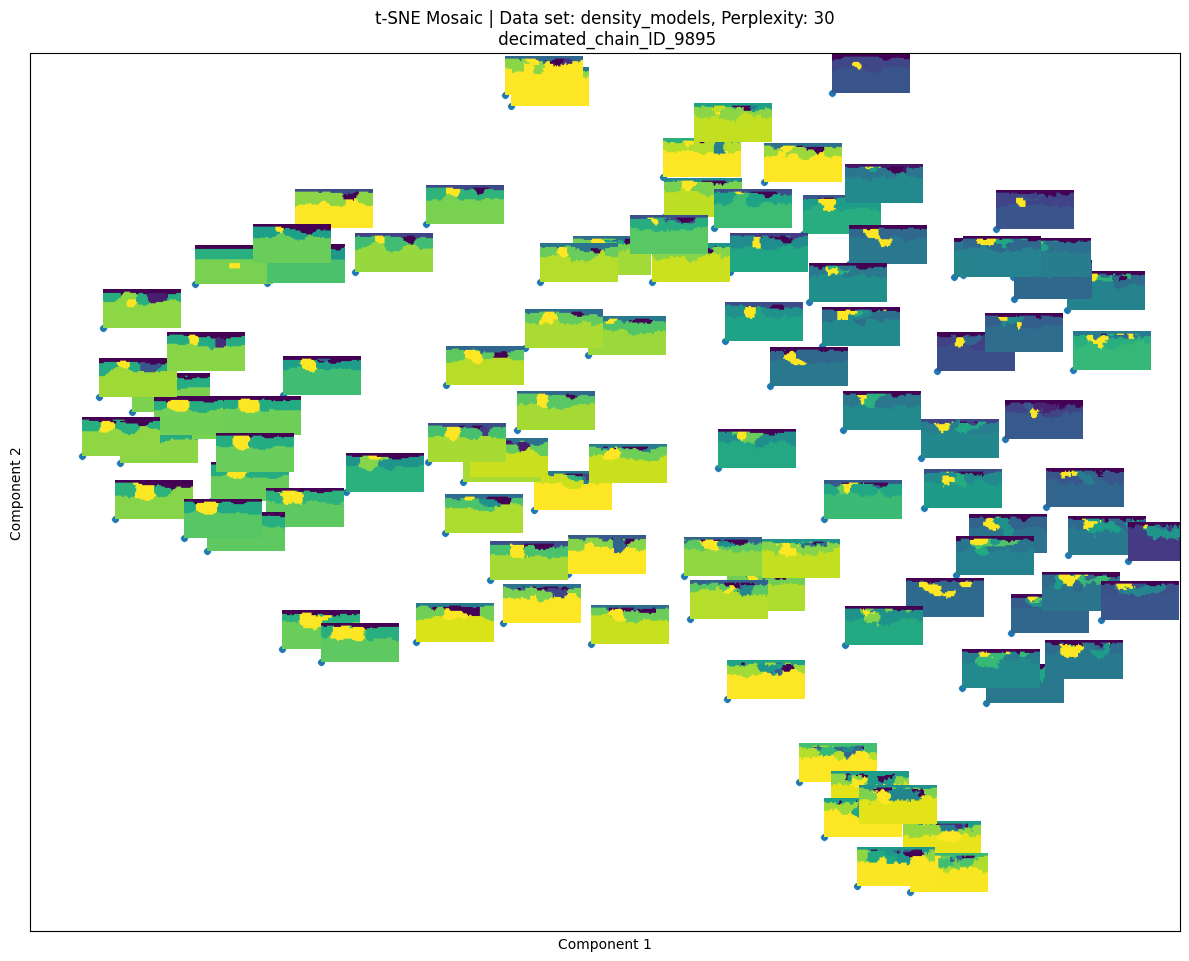

In [37]:
# Plotting tsne mosaic
# Set plotting parameters. 

# Controls the size of the insets where the slices will be plotted. 
# e.g., sizex, sizey = 1., 1. will make each inset a square.
sizex=1.0
sizey=1/2.0

# Marker properties. 
transparency_marker=1.
size_marker=30.

# Plot the t-SNE Mosaic.
# Size of the figure. 
fig_w=12
fig_h=12

title = "t-SNE Mosaic | Data set: %s, Perplexity: %i\n %s"%(data_type, 30., save_dir)

plot_tsne_static(df_tsne_density, sizex, sizey,
                    transparency_marker, size_marker,
                    fig_w, fig_h, title)

In [38]:
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
import base64
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from tqdm import tqdm

# Ensure notebook output is rendered correctly
output_notebook()

# Interactive plot | plotting all points + sampled images
def plot_tsne_interactive(df_tsne, file_prefix, data_type, perplexity, nb_name, sizex=1., sizey=0.5):
    tile_size_units = "data"  # options: "data", "screen"

    if tile_size_units == 'data':
        dh_units, dw_units = 'data', 'data'
        dw, dh = sizex, sizey
    elif tile_size_units == 'screen':
        dh_units, dw_units = 'screen', 'screen'
        dw, dh = 20, 20  # display size of each tile in pixels.

    nb_name = 'data decimation= ' + str(nb_name)
    title = f"t-SNE Mosaic | Data set: {file_prefix} {data_type}, Perplexity: {perplexity} \n REF: {nb_name}"

    # Create figure object
    p = figure(width=800, height=600, title=title)

    # Plot scatter points
    p.scatter("comp_1", "comp_2", source=df_tsne,
              fill_color="black",
              line_alpha=0.6,
              fill_alpha=0.6,
              size=4)

    # Plot images based on the coordinates
    for i, row in tqdm(df_tsne.iterrows(), total=df_tsne.shape[0]):
        img_temp = row["image"].split("data:image/png;base64,")[1]
        bytes_decoded = base64.b64decode(img_temp)
        img_temp = Image.open(BytesIO(bytes_decoded))
        img_temp = np.array(img_temp.convert("L"))[::-1, :]  # to mimic "origin=lower"

        p.image(image=[img_temp],
                x=row["comp_1"], y=row["comp_2"], dh_units=dh_units, dw_units=dw_units,
                dw=dw, dh=dh, origin="top_left", palette="Viridis256", dilate=True)


    return p, title


Loading BokehJS ...

In [39]:
size_x = 1.0
size_y = 0.5 
p, title = plot_tsne_interactive(df_tsne_density,file_prefix,data_type, perplexity,decimate, sizex=size_x, sizey=size_y)
# Show the interactive plot
show(p)

# comment this line if you want to save the html 
output_file(filename=str(file_prefix)+"_interactive.html")#
save(p)
print('Note that the atlas html is automatically saved in the current working directory')

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 62.16it/s]


Note that the atlas html is automatically saved in the current working directory
